In [1]:
pip install pandas geopandas pyarrow shapely matplotlib jupyter

  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached websocket_client-1.9.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached markupsafe-3.0.3-cp314-cp314-win_amd64.whl.metadata (2.8 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached beautifulsoup4-4.14.3-py3-none-any.whl.metadata (3.8 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached soupsieve-2.8.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached typing_extensions-4.15.0-py3-none


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import geopandas as gpd

print("All libraries loaded")

All libraries loaded


In [3]:
df = pd.read_parquet("../data/raw/processed_PFAs.parquet")

df.head()

,study_id,year,date,name,category,lat,lon,city,country,type,sector,measurement location type,substance,value,measurement units,Oceanic Terrestrial Flag,PFA type
0,10,2018,NaN,Maes,Known,50.808932,3.352552,Zwevegem,Belgium,Industrial site,Finishing of textiles,Surface water,PFOA,90.0,ng/l,Terrestrial,Perfluoroalkyl PFAs
1,10,2018,NaN,Maes,Known,50.808932,3.352552,Zwevegem,Belgium,Industrial site,Finishing of textiles,Surface water,PFOS,40.0,ng/l,Terrestrial,Perfluoroalkyl PFAs
2,10,2017,NaN,Tarkett,Known,51.016507,4.088303,Dendermonde,Belgium,Industrial site,Finishing of textiles,Surface water,PFOA,200.0,ng/l,Terrestrial,Perfluoroalkyl PFAs
3,10,2016,NaN,Ververijen Escotex,Known,51.042282,3.548967,Deinze,Belgium,Industrial site,Finishing of textiles,Surface water,PFOA,41400.0,ng/l,Terrestrial,Perfluoroalkyl PFAs
4,10,2016,NaN,Ververijen Escotex,Known,51.042282,3.548967,Deinze,Belgium,Industrial site,Finishing of textiles,Surface water,PFOS,500.0,ng/l,Terrestrial,Perfluoroalkyl PFAs


In [4]:
df.shape

(3815352, 17)

In [5]:
df.columns

Index(['study_id', 'year', 'date', 'name', 'category', 'lat', 'lon', 'city',
       'country', 'type', 'sector', 'measurement location type', 'substance',
       'value', 'measurement units', 'Oceanic Terrestrial Flag', 'PFA type'],
      dtype='str')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3815352 entries, 0 to 3815351
Data columns (total 17 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   study_id                   int64  
 1   year                       int64  
 2   date                       str    
 3   name                       str    
 4   category                   str    
 5   lat                        float64
 6   lon                        float64
 7   city                       str    
 8   country                    str    
 9   type                       str    
 10  sector                     str    
 11  measurement location type  str    
 12  substance                  str    
 13  value                      float64
 14  measurement units          str    
 15  Oceanic Terrestrial Flag   str    
 16  PFA type                   str    
dtypes: float64(3), int64(2), str(12)
memory usage: 909.7 MB


In [6]:
df.isnull().sum()

study_id                           0
year                               0
date                          132012
name                          179770
category                           0
lat                           106448
lon                           106448
city                         2521516
country                         3947
type                               0
sector                       3815335
measurement location type          0
substance                          0
value                        3185371
measurement units                  0
Oceanic Terrestrial Flag           0
PFA type                           0
dtype: int64

In [7]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [8]:
df = df.dropna(subset=["lat", "lon"])

In [9]:
df = df.dropna(subset=["value"])

In [10]:
df.shape

(612930, 17)

In [11]:
df = df.drop(columns=["sector", "city"])

In [12]:
df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
df["lon"] = pd.to_numeric(df["lon"], errors="coerce")

In [13]:
import geopandas as gpd

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"
)

<Axes: >

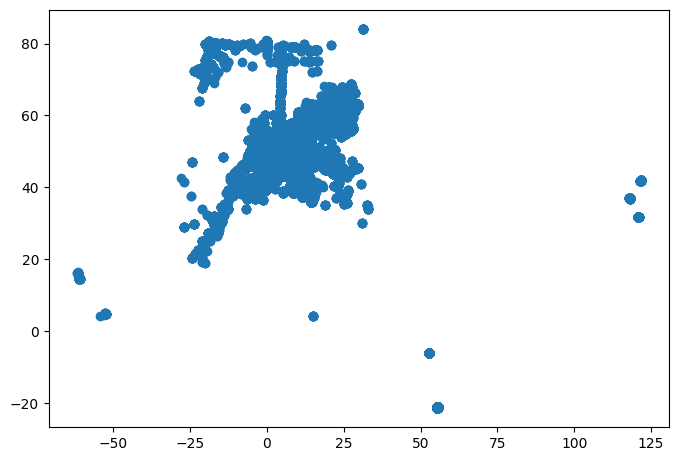

In [14]:
gdf.plot(figsize=(8,6))

In [15]:
gdf["substance"].unique()

<ArrowStringArray>
[                                                                                                                       'PFOA',
                                                                                                                        'PFOS',
                                                                                                                       'PFHxA',
                                                                                                                       'PFHxS',
                                                                                                                        'PFBS',
                                     'Oxirane, (2,2,3,3,4,4,5,5,6,6,7,7,8,8,9,9,10,10,11,11,11-heneicosafluoroundecyl)- (9CI)',
                                                   '4,4,5,5,6,6,7,7,8,8,9,9,10,10,11,11,11-Heptadecafluoroundecanoyl chloride',
                                             '4-Bromo-2-[4,4,5,5,6,6,7,7,8,9,9,9-dode

In [16]:
gdf["substance"].value_counts()

substance
PFOS                                                                                                                           134330
PFOA                                                                                                                           113207
PFHxA                                                                                                                           62537
PFHxS                                                                                                                           37143
PFBA                                                                                                                            35776
                                                                                                                                ...  
EtFOSAA_linear                                                                                                                      1
EtFOSAA_branched                                    

In [17]:
major_pfas = ["PFOA", "PFOS", "PFNA", "PFHxS", "PFHpA", "PFBS", "PFDA"]

In [18]:
gdf = gdf[gdf["substance"].isin(major_pfas)]

In [19]:
gdf["substance"].value_counts()

substance
PFOS     134330
PFOA     113207
PFHxS     37143
PFHpA     33832
PFBS      32299
PFNA      10367
PFDA       8086
Name: count, dtype: int64

In [20]:
gdf = gdf.reset_index(drop=True)

In [21]:
gdf.to_csv("pfas_major_compounds.csv", index=False)

In [22]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point
from scipy.interpolate import griddata
import os

# -----------------------------
# 1. CLEAN DATASET
# -----------------------------

gdf = gdf.dropna(subset=["substance", "value", "lat", "lon"])
gdf = gdf.reset_index(drop=True)

# -----------------------------
# 2. KEEP ONLY MAJOR PFAS
# -----------------------------

major_pfas = ["PFOS", "PFOA", "PFHxS", "PFHpA", "PFBS", "PFNA", "PFDA"]

gdf = gdf[gdf["substance"].isin(major_pfas)]

print(gdf["substance"].value_counts())

# -----------------------------
# 3. CREATE OUTPUT FOLDER
# -----------------------------

os.makedirs("pfas_outputs", exist_ok=True)

# -----------------------------
# 4. PROCESS EACH PFAS
# -----------------------------

for substance in major_pfas:

    print(f"Processing {substance}")

    # Filter dataset
    df = gdf[gdf["substance"] == substance]

    # -----------------------------
    # 5. AGGREGATE BY LOCATION
    # -----------------------------

    agg = df.groupby(["lat","lon"])["value"].mean().reset_index()

    # -----------------------------
    # 6. CONVERT TO GEODATAFRAME
    # -----------------------------

    geometry = [Point(xy) for xy in zip(agg.lon, agg.lat)]

    agg_gdf = gpd.GeoDataFrame(
        agg,
        geometry=geometry,
        crs="EPSG:4326"
    )

    # Save cleaned spatial dataset
    agg_gdf.to_file(
        f"pfas_outputs/{substance}_points.geojson",
        driver="GeoJSON"
    )

    # -----------------------------
    # 7. PREPARE INTERPOLATION
    # -----------------------------

    coords = np.array(list(zip(agg_gdf.geometry.x, agg_gdf.geometry.y)))
    values = agg_gdf["value"].values

    grid_x, grid_y = np.mgrid[
        coords[:,0].min():coords[:,0].max():100j,
        coords[:,1].min():coords[:,1].max():100j
    ]

    # -----------------------------
    # 8. RUN INTERPOLATION
    # -----------------------------

    grid_z = griddata(coords, values, (grid_x, grid_y), method="cubic")

    # -----------------------------
    # 9. GENERATE HEATMAP
    # -----------------------------

    plt.figure(figsize=(8,6))

    plt.imshow(
        grid_z.T,
        extent=(
            coords[:,0].min(),
            coords[:,0].max(),
            coords[:,1].min(),
            coords[:,1].max()
        ),
        origin="lower"
    )

    plt.colorbar(label=f"{substance} concentration")
    plt.title(f"{substance} Spatial Distribution")

    plt.savefig(
        f"pfas_outputs/{substance}_heatmap.png",
        dpi=300
    )

    plt.close()

print("All PFAS processing complete.")

substance
PFOS     134330
PFOA     113207
PFHxS     37143
PFHpA     33832
PFBS      32299
PFNA      10367
PFDA       8086
Name: count, dtype: int64
Processing PFOS
Processing PFOA
Processing PFHxS
Processing PFHpA
Processing PFBS
Processing PFNA
Processing PFDA
All PFAS processing complete.


In [23]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
print(gdf.columns)

Index(['study_id', 'year', 'date', 'name', 'category', 'lat', 'lon', 'country',
       'type', 'measurement_location_type', 'substance', 'value',
       'measurement_units', 'oceanic_terrestrial_flag', 'pfa_type',
       'geometry'],
      dtype='str')


In [1]:
df.shape

NameError: name 'df' is not defined